In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/iris/database.sqlite
/kaggle/input/iris/Iris.csv


In [2]:
data = pd.read_csv('/kaggle/input/iris/Iris.csv')
data.head(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
data.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [4]:
unsupervised_data = data.copy()
unsupervised_data.drop('Species',axis=1,inplace=True)
unsupervised_data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,1,5.1,3.5,1.4,0.2
1,2,4.9,3.0,1.4,0.2
2,3,4.7,3.2,1.3,0.2
3,4,4.6,3.1,1.5,0.2
4,5,5.0,3.6,1.4,0.2


In [5]:
X = unsupervised_data[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]

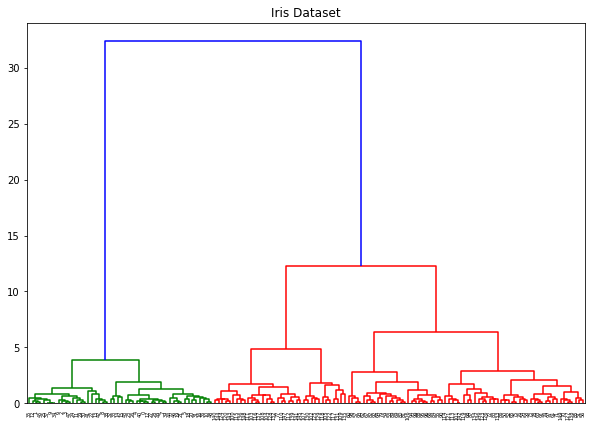

In [6]:
import scipy.cluster.hierarchy as shc

plt.figure(figsize=(10, 7))
plt.title("Iris Dataset")
dend = shc.dendrogram(shc.linkage(X, method='ward'))

In [7]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters=3, affinity='euclidean', linkage='ward')
clusters = cluster.fit_predict(X)

In [8]:
unsupervised_data['Clusters']=clusters
unsupervised_data['Cluster_name'] = unsupervised_data['Clusters'].map({0:'Cluster 1',1:'Cluster 2',2:'Cluster 3'})
unsupervised_data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Clusters,Cluster_name
0,1,5.1,3.5,1.4,0.2,1,Cluster 2
1,2,4.9,3.0,1.4,0.2,1,Cluster 2
2,3,4.7,3.2,1.3,0.2,1,Cluster 2
3,4,4.6,3.1,1.5,0.2,1,Cluster 2
4,5,5.0,3.6,1.4,0.2,1,Cluster 2


In [9]:
data.head(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [10]:
for value in data['Species'].unique():
    print(value)

Iris-setosa
Iris-versicolor
Iris-virginica


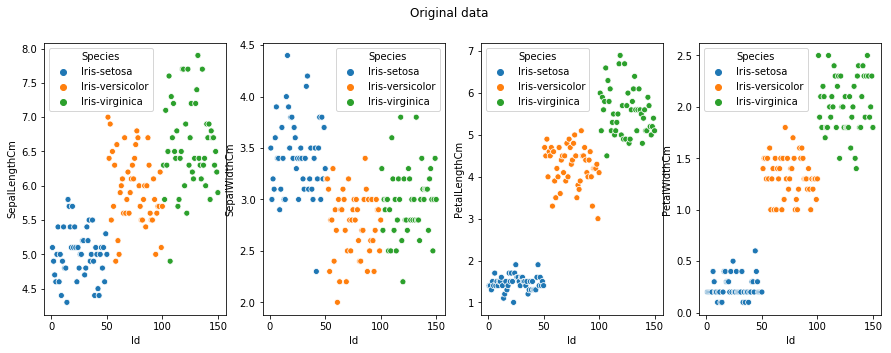

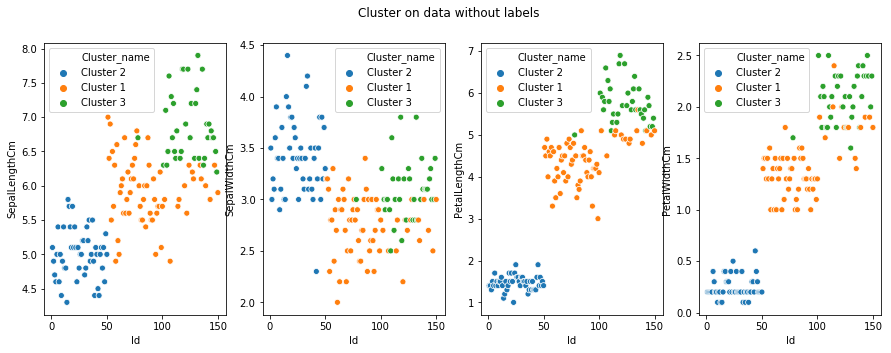

In [11]:
f, axes = plt.subplots(1,4,figsize=(15,5))
f.suptitle("Original data")
y = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
hue = 'Species'
ax = 0
for y in y:
    sns.scatterplot(x = 'Id', y = y, hue = hue, data = data, ax = axes[ax])
    ax = ax + 1
    
f, axes = plt.subplots(1,4,figsize=(15,5))
f.suptitle("Cluster on data without labels")
y = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
hue = 'Cluster_name'
ax = 0
for y in y:
    sns.scatterplot(x = 'Id', y = y, hue = hue, data = unsupervised_data, ax = axes[ax])
    ax = ax + 1